```
<02_Apple.ipynb>

제미나이 의존도: 40-50%

01_Crawling.ipynb에서 크롤링했던 이미지를 matplotlib 라이브러리를 통해 직접 화면에도 띄워보는 연습을 했습니다.

제미나이의 도움을 최소한으로 하면서 데이터셋을 구축했지만, 어려움을 많이 겪었습니다.

데이터도 34개라서 터무니없는 데이터 양입니다.
그리고 신선한 사과"뿐"이라서 정답(라벨)도 0(신선한 사과) 뿐입니다.
하지만 저는 처음부터 완벽한 모델을 만들 생각이 아닌, 모델이 학습을 하면서 Loss가 줄어드는것을 보고싶었기 때문입니다.

Epoch 1/5 | Loss: 0.1817
Epoch 2/5 | Loss: 0.0000
Epoch 3/5 | Loss: 0.0000
Epoch 4/5 | Loss: 0.0000
Epoch 5/5 | Loss: 0.0000

에폭1에서 Loss가 나왔고, 모델은 정답이 0(신선한 사과) 아니면 1(사실상 없음)이기 때문에 에폭2부터는 Loss가 0이 나오는 모습입니다.
```

In [2]:
import glob

image_path = "apple_images/"

image_paths = sorted(glob.glob(image_path + "*.jpg"))

print(len(image_paths))

99


In [1]:
!pwd

/Users/jeongjaehun/Crawling


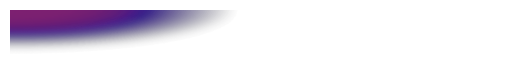

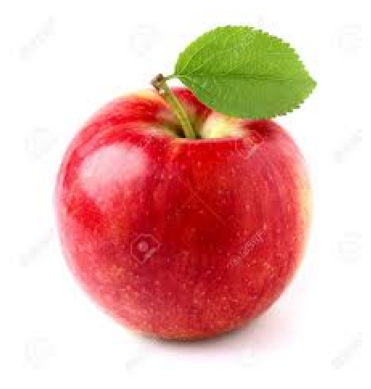

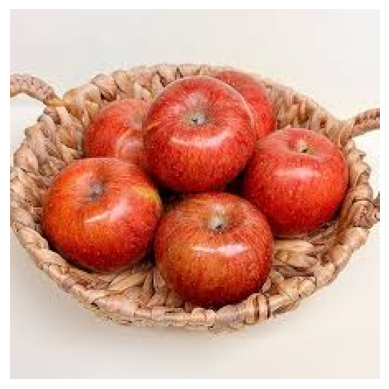

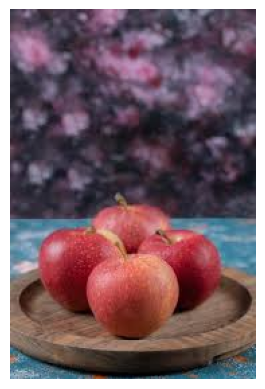

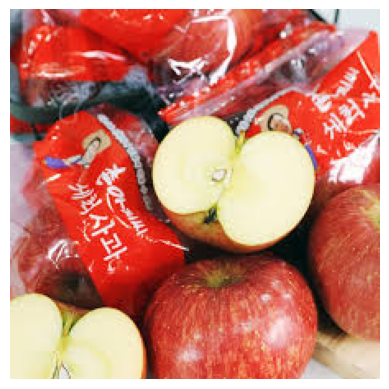

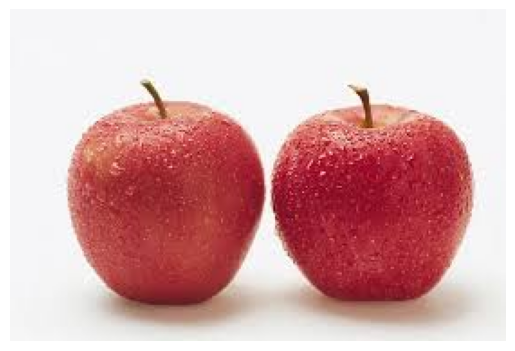

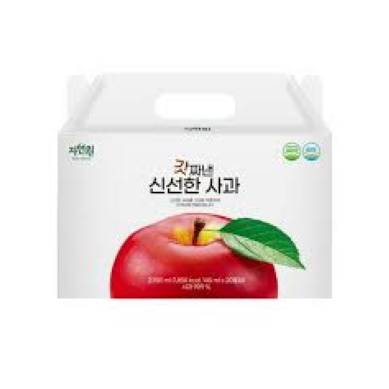

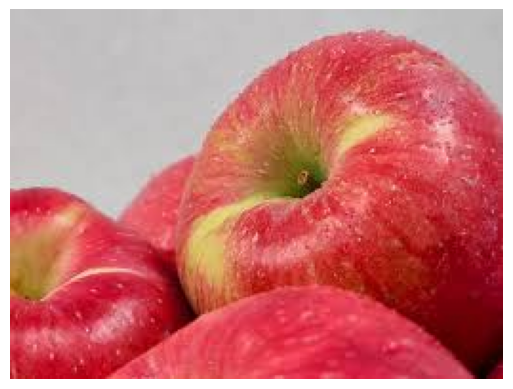

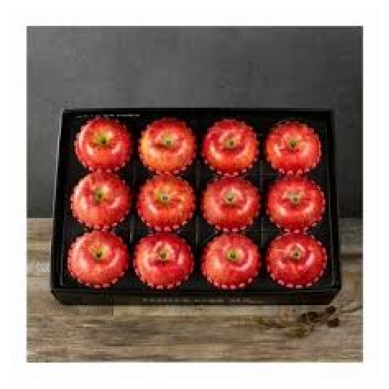

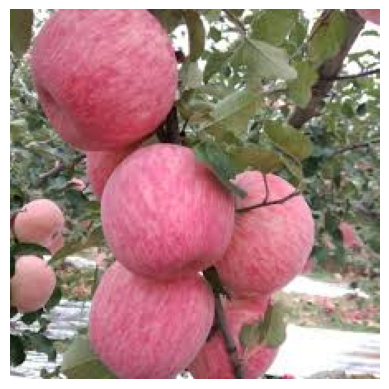

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sorted_images_path = sorted(images)

for i, path in enumerate(sorted_image_paths):
    img = mpimg.imread(path)

    plt.imshow(img)
    plt.axis('off')
    plt.show()
    if i >= 9:
        break;

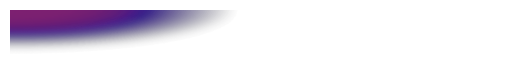

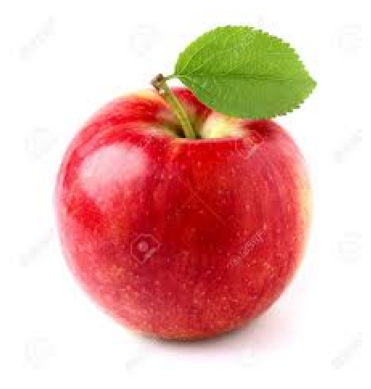

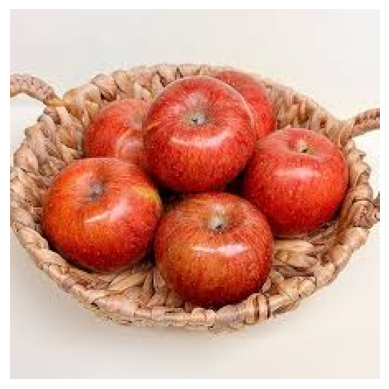

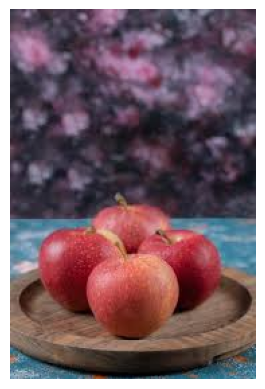

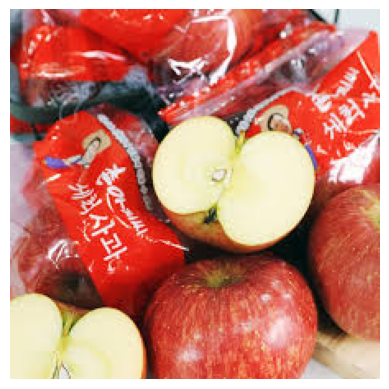

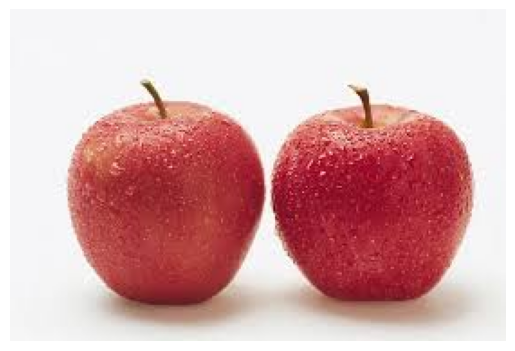

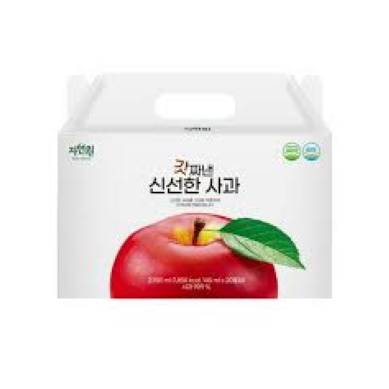

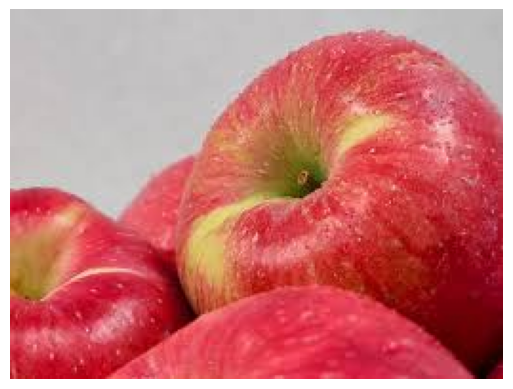

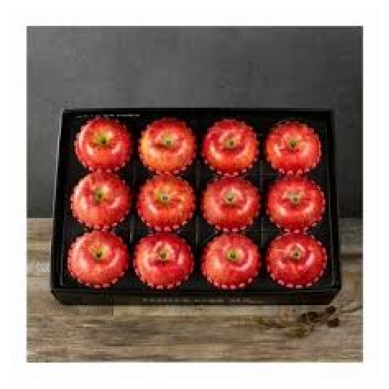

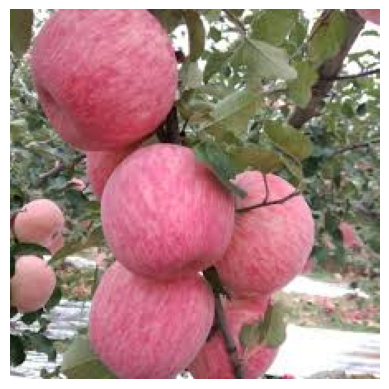

In [24]:
import matplotlib.pyplot as plt
from PIL import Image

sorted_images_path = sorted(images)

for i, path in enumerate(sorted_images_path):
    img = Image.open(path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    if i >= 9:
        break;


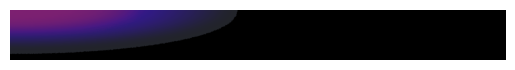

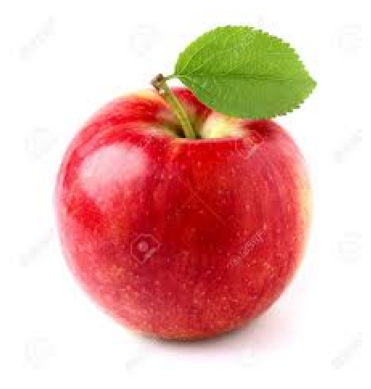

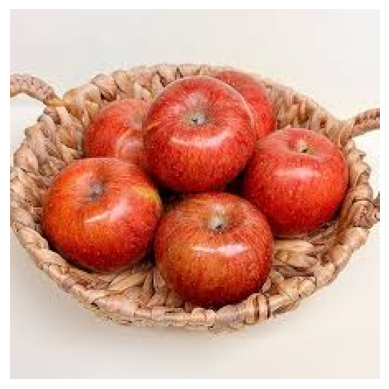

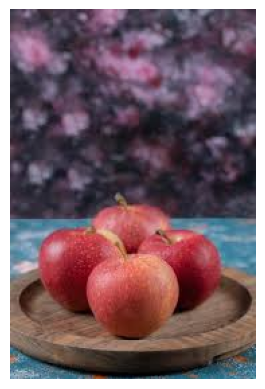

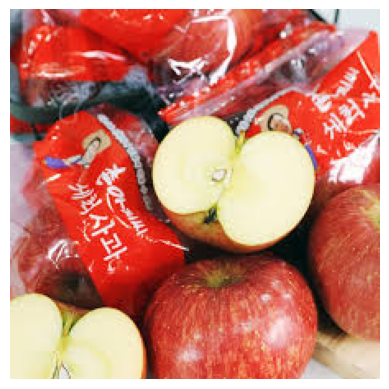

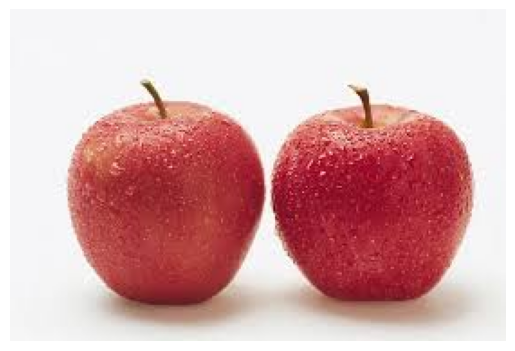

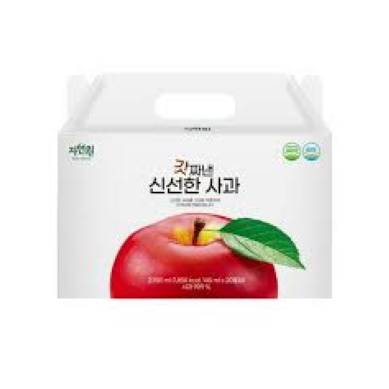

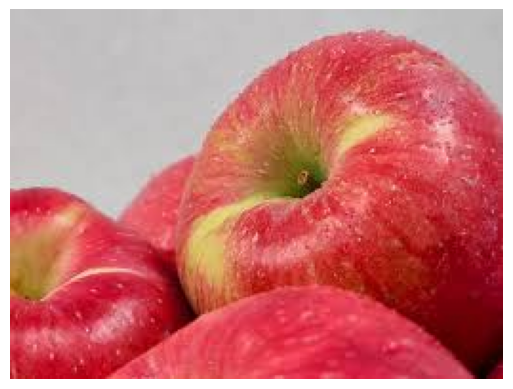

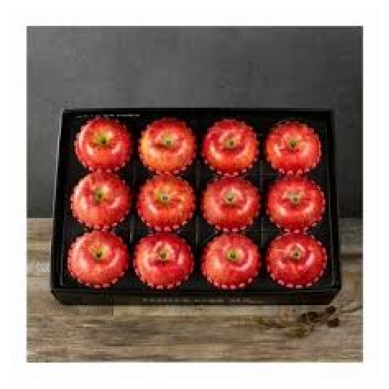

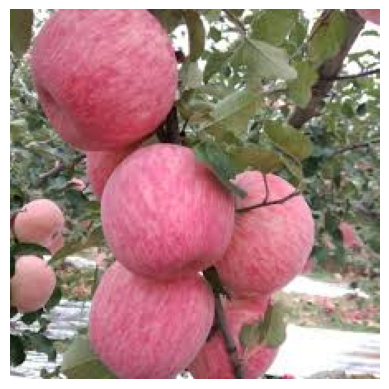

In [25]:
import matplotlib.pyplot as plt
import cv2

sorted_images_path = sorted(images)

for i, path in enumerate(sorted_image_paths):
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
    if i >= 9:
        break


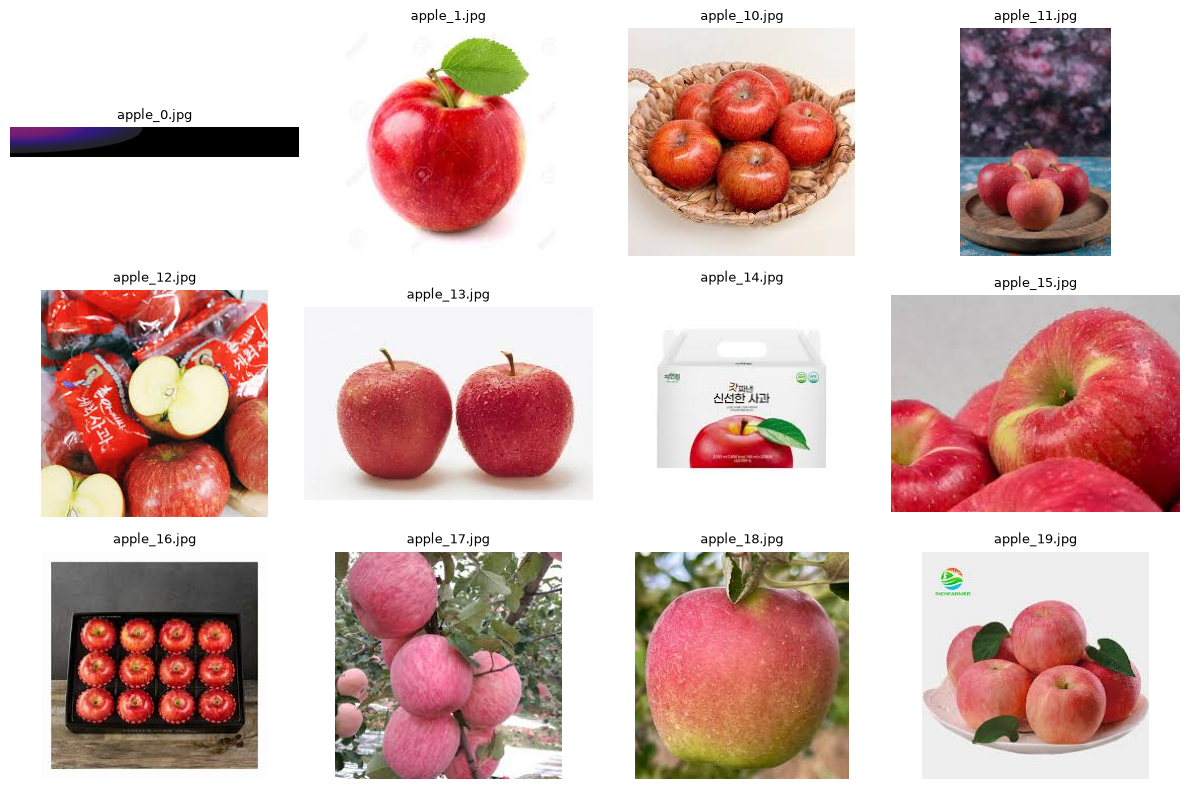

In [3]:
import matplotlib.pyplot as plt
import cv2
import os

max_length = 12
images_to_show = image_paths[:max_length]

rows = 3
cols = 4

plt.figure(figsize=(12, 8))
for idx, path in enumerate(images_to_show):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, idx + 1)

    plt.imshow(img_rgb)

    plt.title(os.path.basename(path), fontsize=9)

    plt.axis('off')

plt.tight_layout()
plt.show()

In [25]:
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

class AppleDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = sorted(glob.glob(os.path.join(root_dir, "*.jpg")))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)
        # 임시 정답 라벨(사과 = 0)을 지정해주기
        label = 0

        return image, torch.tensor(label, dtype=torch.long)

train_transform = transforms.Compose([
    transforms.Resize((128, 128)), 
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [26]:
from torch.utils.data import DataLoader
train_dataset = AppleDataset("apple_images/", train_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

In [27]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([8, 3, 128, 128])
torch.Size([8])


In [15]:
test_dataset = AppleDataset("apple_images/", transform=None)
broken_count = 0
for i in range(len(test_dataset)):
    img_path = test_dataset.image_paths[i]
    img = Image.open(img_path)

    if img.mode != 'RGB':
        # print(f"인덱스: {i} | 파일명: {img_path} | 이미지 모드: {img.mode}")
        os.remove(img_path)
        # broken_count += 1
# print(f"broken_count: {broken_count}")
print(len(test_dataset))

34


In [18]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"device: {device}")

device: mps


In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AppleCNN(nn.Module):
    def __init__(self):
        super().__init__() # (8, 3, 128, 128) -> (8, 16, 64, 64) -> (8, 32, 32, 32)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.fc = nn.Linear(32 * 32 * 32, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

model = AppleCNN().to(device)

In [45]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [46]:
epochs = 5

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader.dataset):.4f}")

Epoch 1/5 | Loss: 0.1817
Epoch 2/5 | Loss: 0.0000
Epoch 3/5 | Loss: 0.0000
Epoch 4/5 | Loss: 0.0000
Epoch 5/5 | Loss: 0.0000
